# Imports

In [179]:
import os
from sklearn import linear_model
import importlib

#Resurse proprii functii scrie in .py

import resurse.dataPlot

importlib.reload(resurse.dataPlot)

import resurse.matrixOperations as opMtx
import resurse.errors as err
import resurse.dataPlot as dp
from resurse.metodaPatratelor import metodaPatratelor
from resurse.readCSV import ReadDoubleInputCSV,ReadSingleInputCSV
from resurse.trainPlots import UniSelectTVdata, BiSelectTVdata , Compare_ValidationVSComputed ,Compare_ValidationVSComputed3D

# Functii pentru probleme : 

## - Model Learning (Metoda Patratelor) - Univariata :

### 1. Tool

In [180]:
#Sursa -  AI-UBB
def UniModelLearningTool(trainInputs, trainOutputs):
    xx = [[el] for el in trainInputs]
    regressor = linear_model.LinearRegression()
    regressor.fit(xx, trainOutputs)
    w0, w1 = regressor.intercept_, regressor.coef_[0]
    return w0, w1, regressor

### 2. Code
used the formulas : 
$$
w_1 = \frac{n \sum_{i=1}^{n} (x^i * y^i) - \sum_{i=1}^{n} x^i * \sum_{i=1}^{n} y^i}
{n \sum_{i=1}^{n} (x^i)^2 - (\sum_{i=1}^{n} x^i)^2}
$$

$$
w_0 = \frac{\sum_{i=1}^{n} y^i - w_1 \sum_{i=1}^{n} x^i}{n}
$$


## Definitions  

- $n$ = Number of training inputs  
- $x_i$ = Input feature at index $i$  
- $y_i$ = Output (target) corresponding to $x_i$  
- $i = 1, 2, \dots, n$ (Index ranging from 1 to $n$)  


In [181]:
def UniModelLearningCode(trainInputs, trainOutputs):
    return metodaPatratelor(trainInputs, trainOutputs)

## - Model Learning (Metoda Patratelor) - Bivariata :

### 1.Tool

In [182]:
def BiModelLearningTool(trainInputsFirst, trainInputsSecond, trainOutputs):
    xx = list([[f, s] for f, s in zip(trainInputsFirst, trainInputsSecond)])
    regressor = linear_model.LinearRegression()
    regressor.fit(xx, trainOutputs)
    w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]

    return w0, w1, w2, regressor

### 2.Code
Pentru cazul unei regresii multi-variate (\(m\) atribute): 
$ f(x, w) = w_0 + w_1 \cdot x_1 + w_2 \cdot x_2 + \dots + w_m \cdot x_m \) $
și un set de date cu \(n\) exemple:

$$
w = (X^T X)^{-1} X^T Y
$$

unde $\( X = (x_{ij}) \), \( Y = (y^i) \), \( i = 1,2,\dots,n \), \( j = 1,2,\dots,m \)$.

In [183]:
def BiModelLearningCode(trainInputsFirst, trainInputsSecond, trainOutputs):
    #matrice de input si output
    X = list([[1, i, j] for i, j in zip(trainInputsFirst, trainInputsSecond)])
    Y = list([x] for x in trainOutputs)
    #apel metoda patratelor prin matrici
    w = opMtx.Biformula(X,Y)
    return w[0][0], w[1][0], w[2][0]

## - Formule

## Regresia Univariata
$$ f(x) = w_0 + w_1*x $$

## Regresia Bivariata
$$ f(x_1,x_2) = w_0 + w_1*x_1 + w_2*x_2 $$

## Functia de eroare:

  $$
  Error = \frac{1}{n} \times \sum_{i=1}^{n}  (y^i - y^i_{computed}) ^ 2 
  $$


## - Problem solving function Univariata

In [184]:
def SolveRegresieUnivariata(filename, inputVariabName, outputVariableName, labelInput, labelOutput, directory='dataLab5'):
    #read Data
    crtDir = os.getcwd()
    filePath = os.path.join(crtDir, directory, filename)
    inputs, outputs = ReadSingleInputCSV(filePath, inputVariabName, outputVariableName)

    #histograms and liniar plot of data
    dp.plotDataHistogram(inputs, labelInput)
    dp.plotDataHistogram(outputs, labelOutput)
    dp.PlotLiniarData(inputs, outputs, labelInput, labelOutput)

    #train inputs , train outputs , validation inputs , validation outputs separation
    TI, TO, VI, VO = UniSelectTVdata(inputs, outputs, labelInput, labelOutput)

    #w1,w2 from tool algorithm for regresion t - tool
    tw0, tw1, regresor = UniModelLearningTool(TI, TO)
    print(f"Functia calculata de tool : f(x) = {tw0} + {tw1} * x = y \n w0 = {tw0} \n w1 = {tw1}")

    #w1,w2 from code algorithm for regresion c - code
    cw0, cw1 = UniModelLearningCode(TI, TO)
    print(f"Functia calculata de code : f(x) = {cw0} + {cw1} * x = y \n w0 = {cw0} \n w1 = {cw1}")

    #Plot pentru Learning data din tool si code si compararea lor
    dp.Compare_LiniarData(TI, TO, tw0, tw1, cw0, cw1, labelInput, labelOutput)
   
    #tool/code compilated values tc = toolComputed , cc = codeComputed
    tc, cc = regresor.predict([[x] for x in VI]),[cw0 + cw1 * x for x in VI]
    
    #view validation data vs computed data
    Compare_ValidationVSComputed(VI, VO, tc, cc, labelInput, labelOutput)

    #Erori outputs
    print("Erori outputs:")
    print(f"Eroare tool manuala : {err.ManualError(tc, VO)}")
    print(f"Eroare tool cu tool : {err.ManualError(cc, VO)}")
    print(f"Eroare code manuala : {err.ToolError(tc, VO)}")
    print(f"Eroare code cu tool : {err.ToolError(tc, VO)}")

## - Problem solving function Bivariata

In [185]:
def SolveRegresieBivariata(filename, inputVariableNameFirst, inputVariableNameSecond, outputVariableName,
                           labelInputFirst, labelInputSecond, labelOuput, directory='datalab5'):
    #read Data
    crtDir = os.getcwd()
    filePath = os.path.join(crtDir, directory, filename)

    inputsFirst, inputsSecond, outputs = ReadDoubleInputCSV(filePath, inputVariableNameFirst, inputVariableNameSecond,
                                                            outputVariableName)

    #histograms and plot
    dp.plotDataHistogram(inputsFirst, labelInputFirst)
    dp.plotDataHistogram(inputsSecond, labelInputSecond)
    dp.plotDataHistogram(outputs, labelOuput)

    #plot data
    dp.Plot3DLiniardata(inputsFirst, inputsSecond, outputs, labelInputFirst, labelInputSecond, labelOuput)

    #train inputs , train outputs , validation inputs , validation outputs
    TIF, TIS, TO, VIF, VIS, VO = BiSelectTVdata(inputsFirst, inputsSecond, outputs, labelInputFirst, labelInputSecond,
                                                labelOuput)
    #w0,w1,w2 from tool algorithm
    tw0, tw1, tw2, regressor = BiModelLearningTool(TIF, TIS, TO)

    print(tw0)
    print(tw1)
    print(tw2)

    #w0,w1,w2 from code algorithm
    cw0, cw1, cw2 = BiModelLearningCode(TIF, TIS, TO)

    print(cw0)
    print(cw1)
    print(cw2)

    #Plot pentru learning data din tool si code si Compararea planurilor lor
    dp.Compare_PlaneData(TIF, TIS, TO, tw0, tw1, tw2, cw0, cw1, cw2, labelInputFirst, labelInputSecond, labelOuput)

    #tool/code compilated values  tc = toolComputed , cc = codeComputed
    tc = regressor.predict([[x, y] for x, y in zip(VIF, VIS)])
    cc = [cw0 + cw1 * x + cw2 * y for x, y in zip(VIF, VIS)]
    
    #view validation data vs computed data
    Compare_ValidationVSComputed3D(VIF, VIS, VO, tc, cc, labelInputFirst, labelInputSecond, labelOuput)

    #Erori outputs
    print("Erori outputs:")
    print(f"Eroare tool manuala : {err.ManualError(tc, VO)}")
    print(f"Eroare tool cu tool : {err.ManualError(cc, VO)}")
    print(f"Eroare code manuala : {err.ToolError(tc, VO)}")
    print(f"Eroare code cu tool : {err.ToolError(tc, VO)}")


# Probleme :

## V1:

### 1. doar de Produsul intern brut 

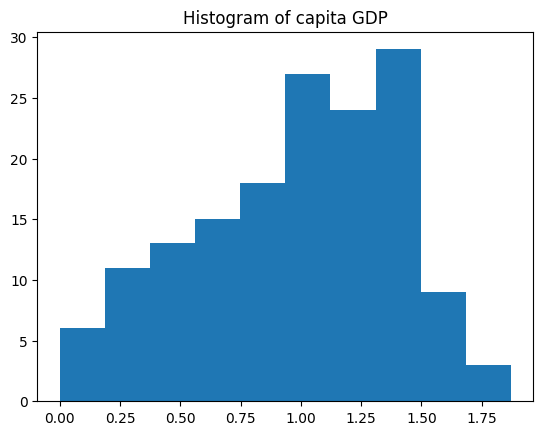

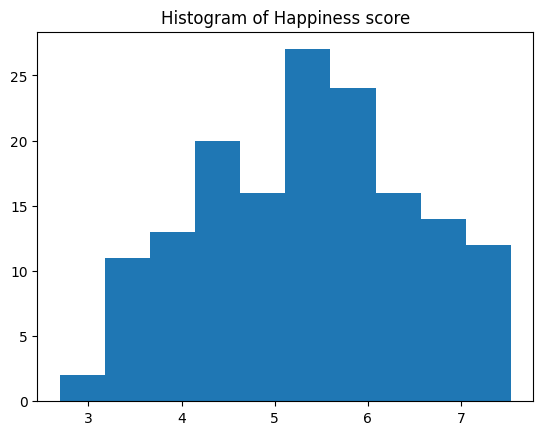

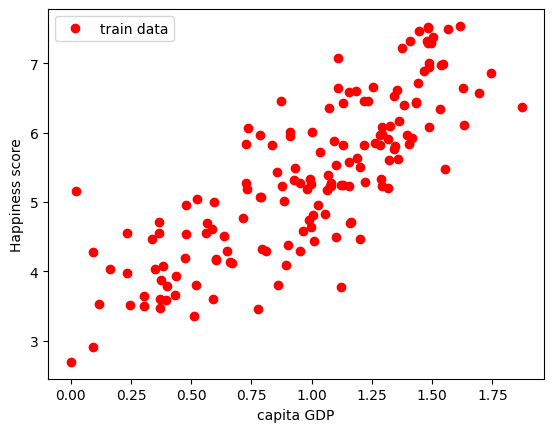

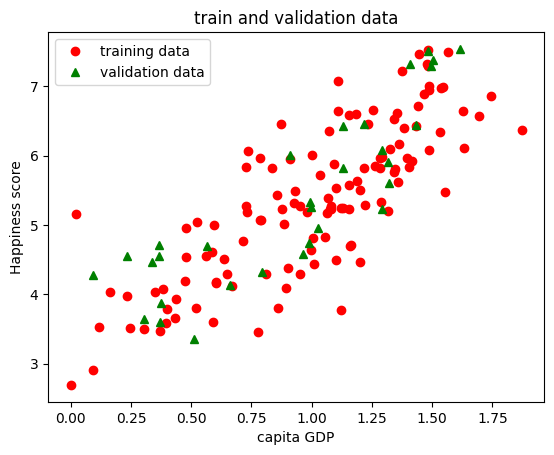

Functia calculata de tool : f(x) = 3.2007686226678995 + 2.1503460961741077 * x = y 
 w0 = 3.2007686226678995 
 w1 = 2.1503460961741077
Functia calculata de code : f(x) = 3.2007686226678964 + 2.150346096174109 * x = y 
 w0 = 3.2007686226678964 
 w1 = 2.150346096174109


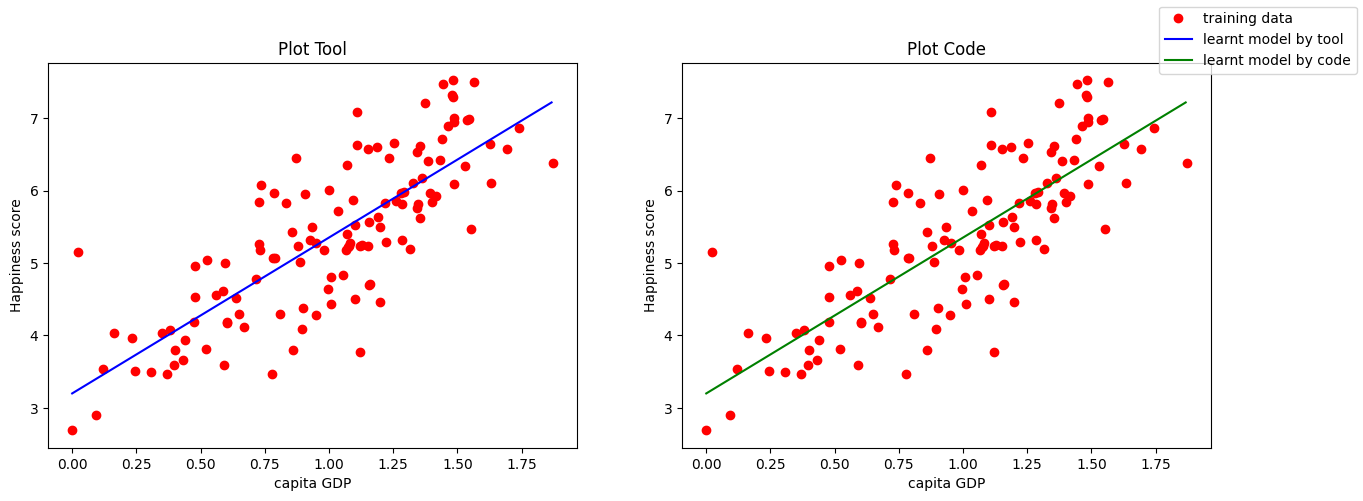

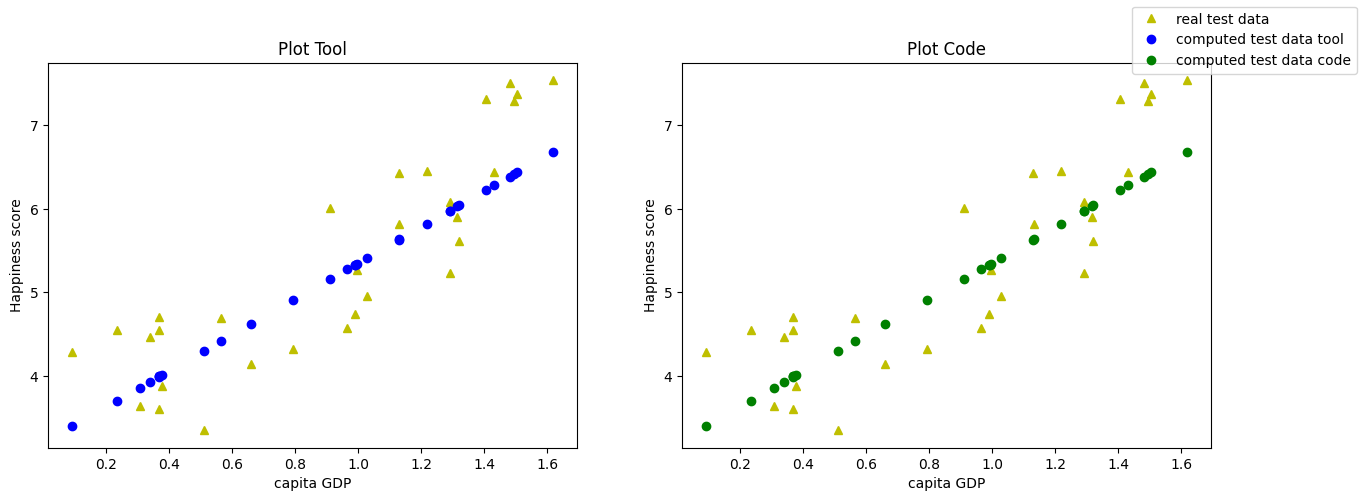

Erori outputs:
Eroare tool manuala : 0.4142120438505252
Eroare tool cu tool : 0.4142120438505258
Eroare code manuala : 0.41421204385052524
Eroare code cu tool : 0.41421204385052524


In [186]:
SolveRegresieUnivariata(filename='v1_world-happiness-report-2017.csv',
                inputVariabName='Economy..GDP.per.Capita.',
                outputVariableName='Happiness.Score',
                labelInput='capita GDP',
                labelOutput='Happiness score')

### 2. doar de caracteristica "Family" 

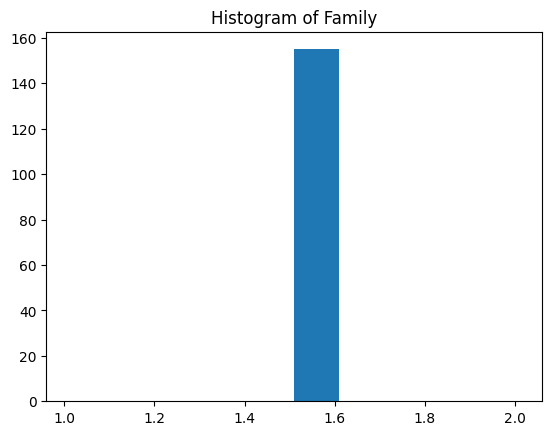

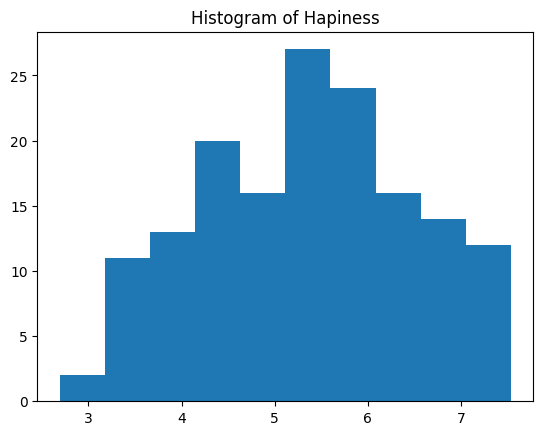

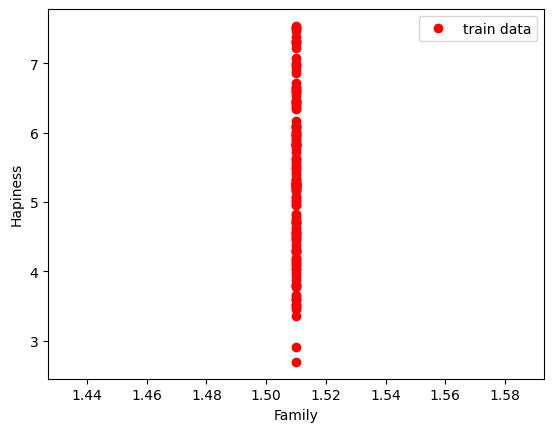

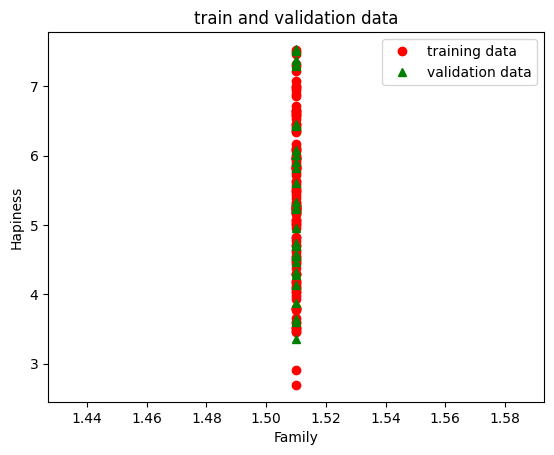

Functia calculata de tool : f(x) = 0.4719180650554877 + 3.2328954364819484 * x = y 
 w0 = 0.4719180650554877 
 w1 = 3.2328954364819484
Functia calculata de code : f(x) = 5.3537258005725805 + 0.0 * x = y 
 w0 = 5.3537258005725805 
 w1 = 0.0


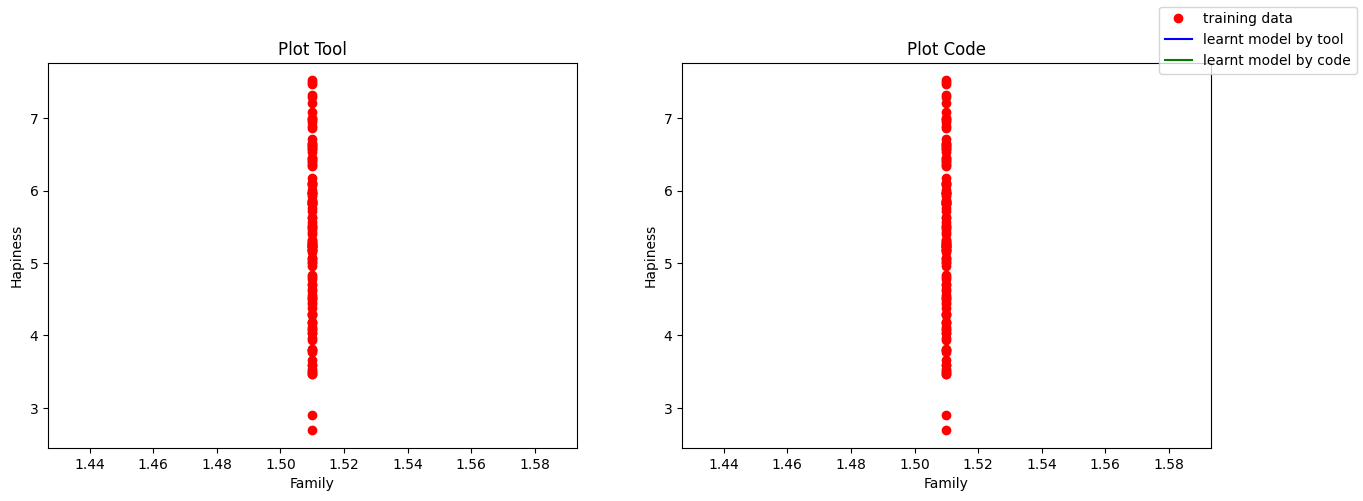

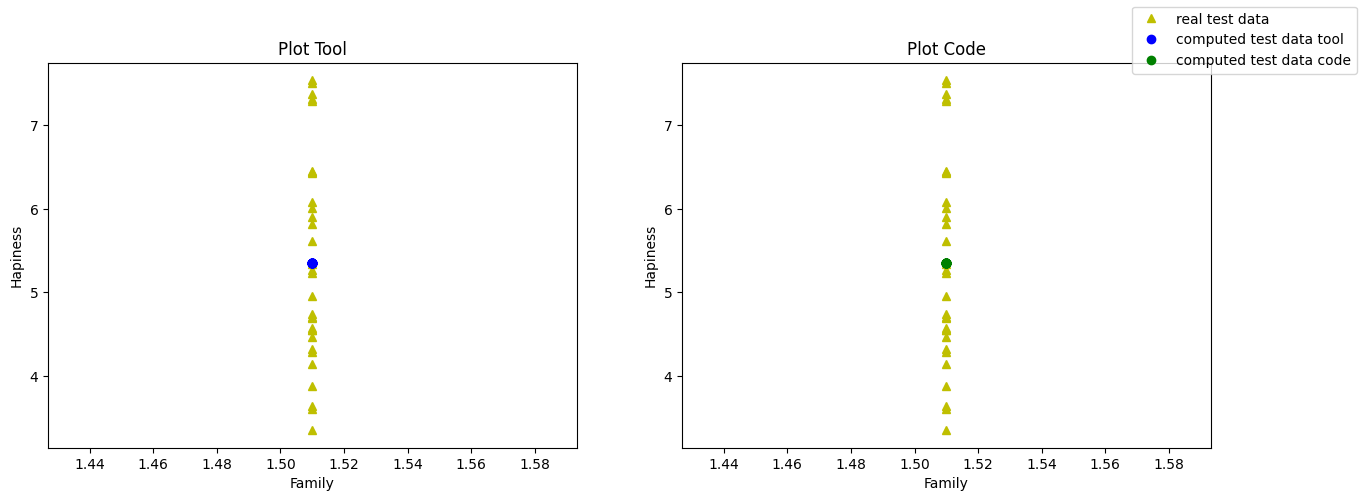

Erori outputs:
Eroare tool manuala : 1.488969965516146
Eroare tool cu tool : 1.488969965516146
Eroare code manuala : 1.488969965516146
Eroare code cu tool : 1.488969965516146


In [187]:
SolveRegresieUnivariata(filename='v1_world-happiness-report-2017.csv',
                inputVariabName='Family',
                outputVariableName='Happiness.Score',
                labelInput='Family',
                labelOutput='Hapiness')

### 3.de Produsul intern brut si de gradul de libertate.

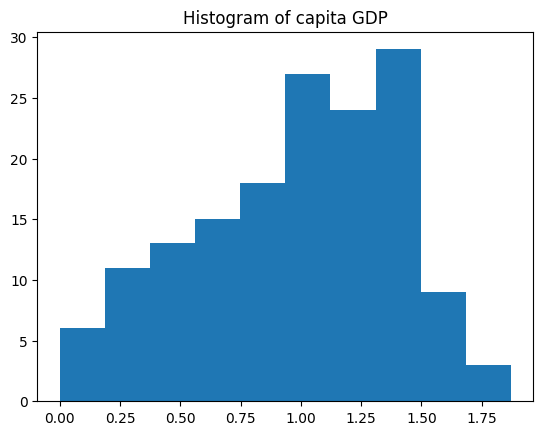

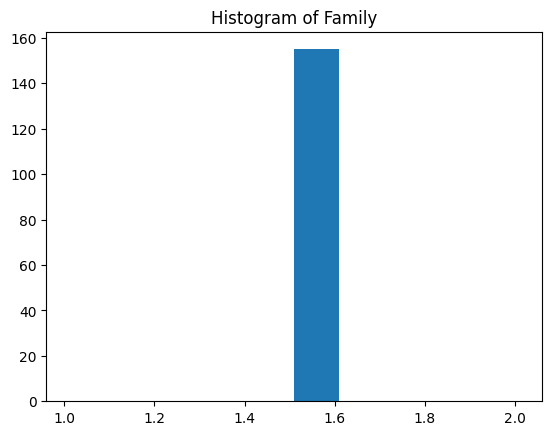

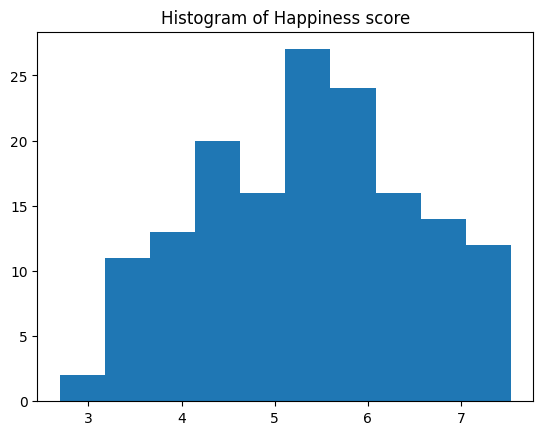

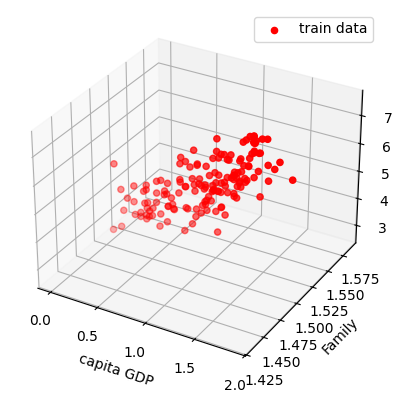

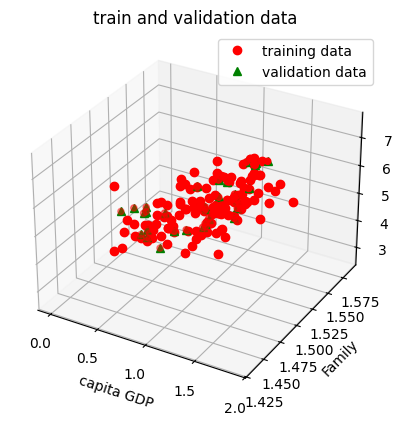

3.2007686226679
2.1503460961741068
0.0
-12.19379684166797
18.70983647368372
16.275042922837898


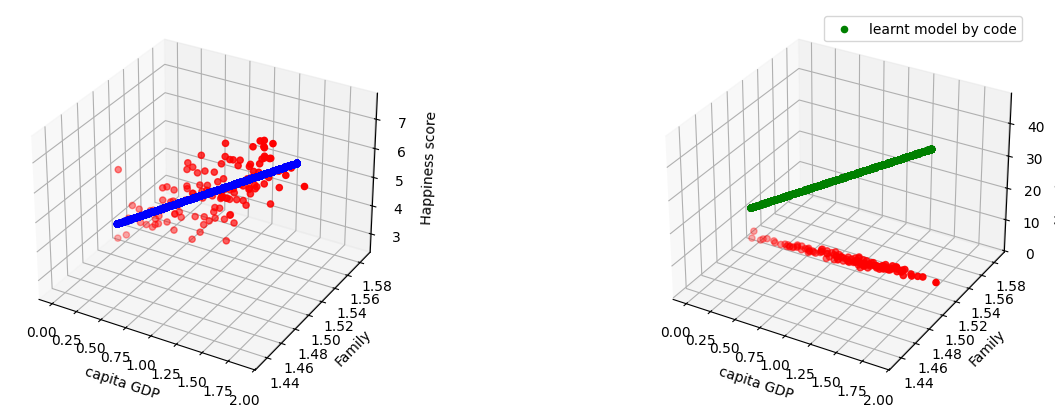

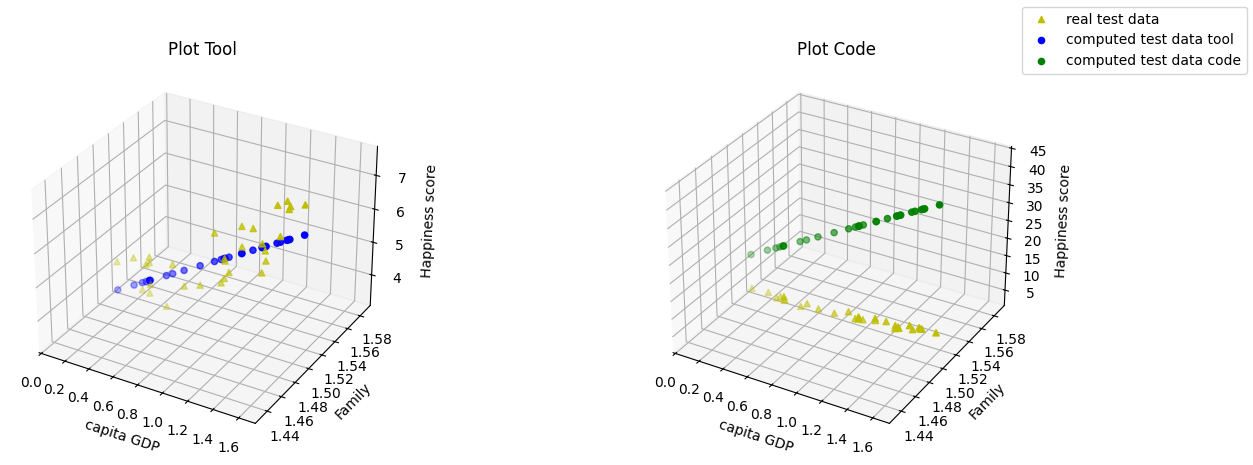

Erori outputs:
Eroare tool manuala : 0.41421204385052524
Eroare tool cu tool : 640.4700245147154
Eroare code manuala : 0.41421204385052535
Eroare code cu tool : 0.41421204385052535


In [188]:
SolveRegresieBivariata(filename='v1_world-happiness-report-2017.csv',
               inputVariableNameFirst='Economy..GDP.per.Capita.',
               inputVariableNameSecond='Family',
               outputVariableName='Happiness.Score',
               labelInputFirst='capita GDP',
               labelInputSecond='Family',
               labelOuput='Happiness score')

## V2:

### 1. doar de Produsul intern brut 

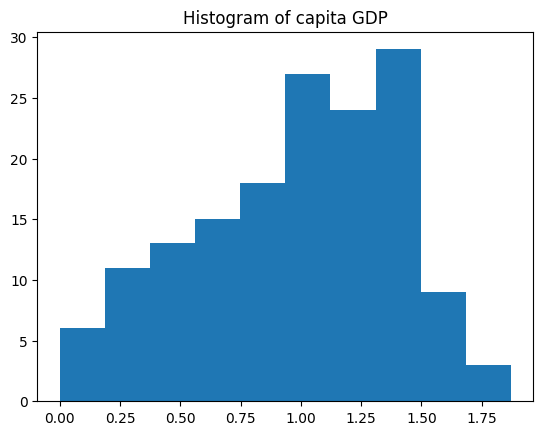

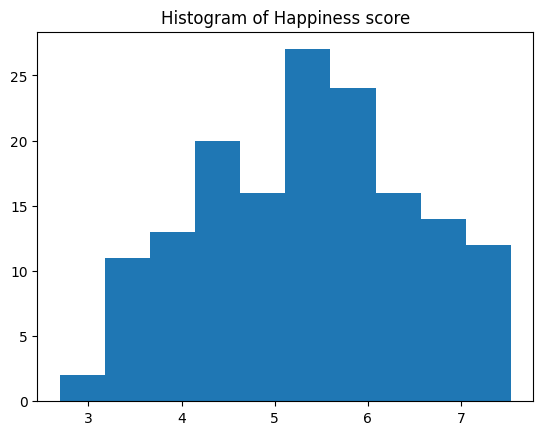

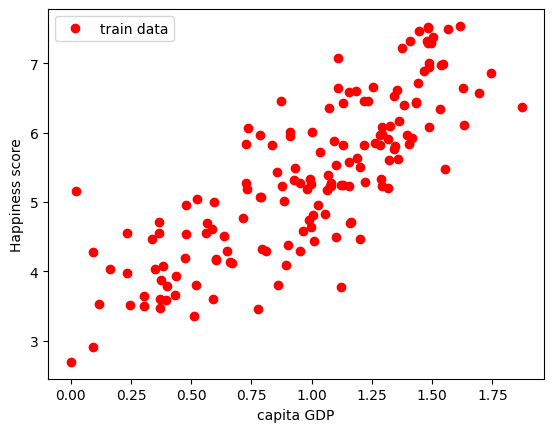

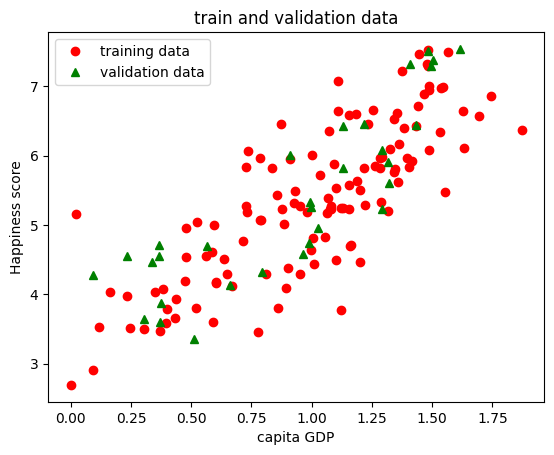

Functia calculata de tool : f(x) = 3.2007686226678995 + 2.1503460961741077 * x = y 
 w0 = 3.2007686226678995 
 w1 = 2.1503460961741077
Functia calculata de code : f(x) = 3.2007686226678964 + 2.150346096174109 * x = y 
 w0 = 3.2007686226678964 
 w1 = 2.150346096174109


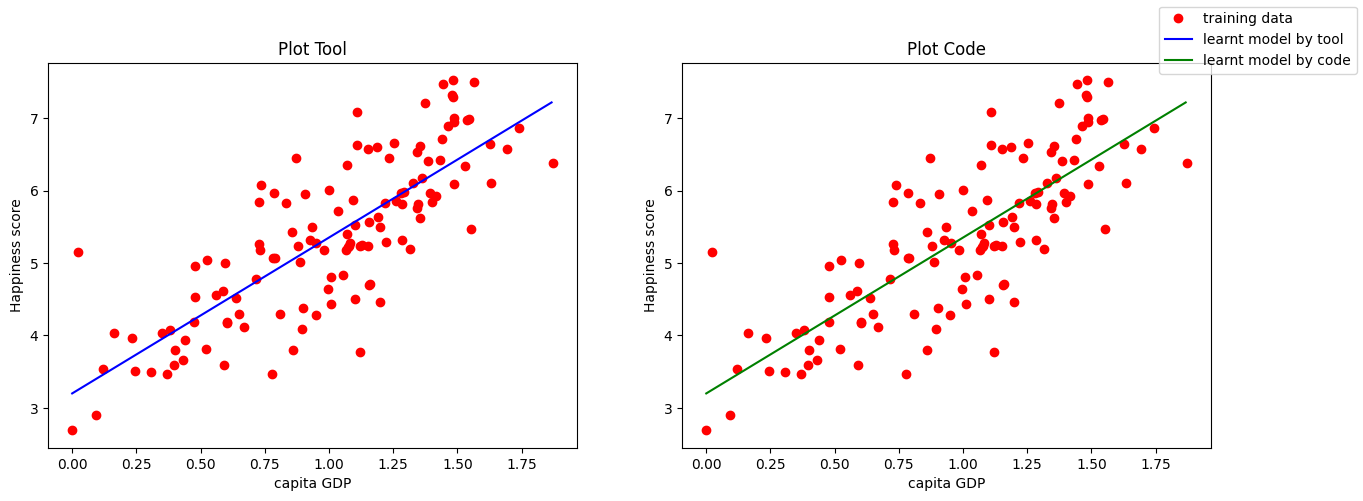

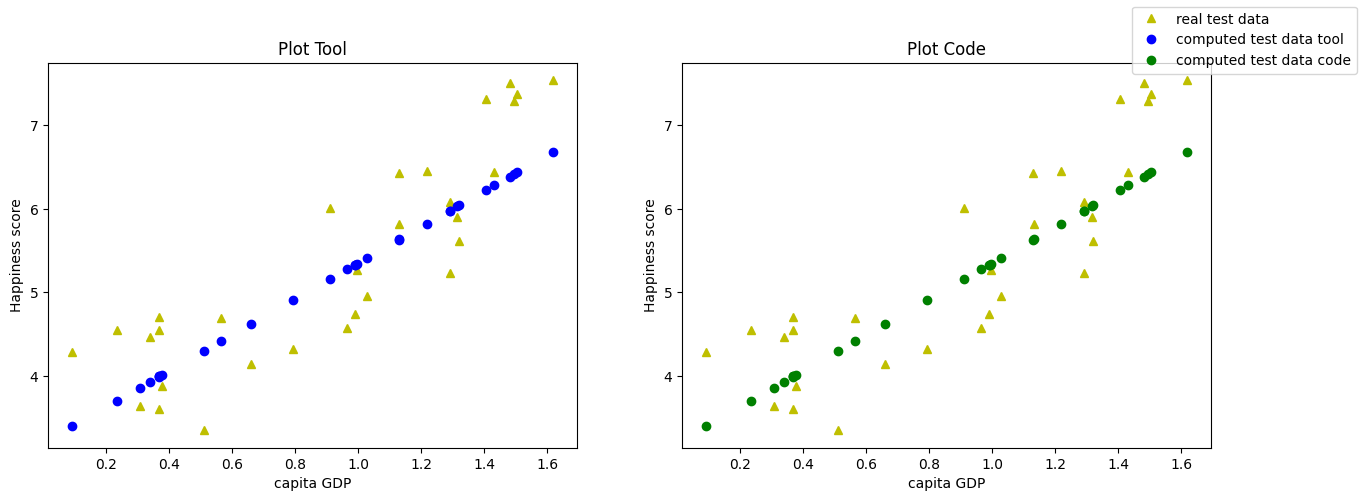

Erori outputs:
Eroare tool manuala : 0.4142120438505252
Eroare tool cu tool : 0.4142120438505258
Eroare code manuala : 0.41421204385052524
Eroare code cu tool : 0.41421204385052524


In [189]:
SolveRegresieUnivariata(filename='v2_world-happiness-report-2017.csv',
                inputVariabName='Economy..GDP.per.Capita.',
                outputVariableName='Happiness.Score',
                labelInput='capita GDP',
                labelOutput='Happiness score')

### 2. doar de caracteristica “Family”

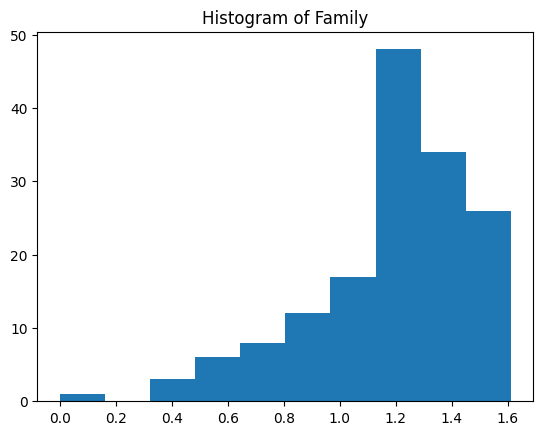

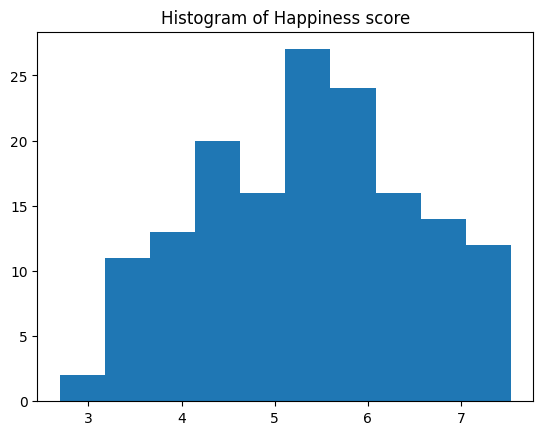

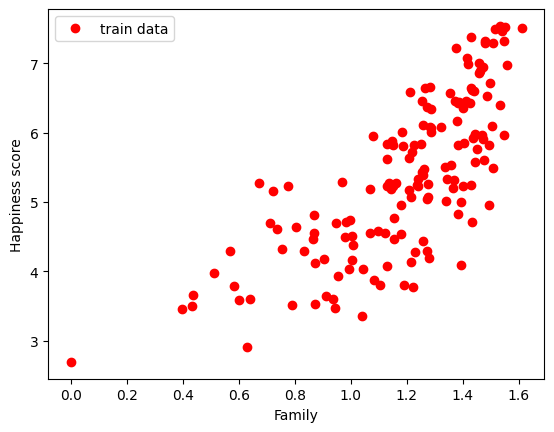

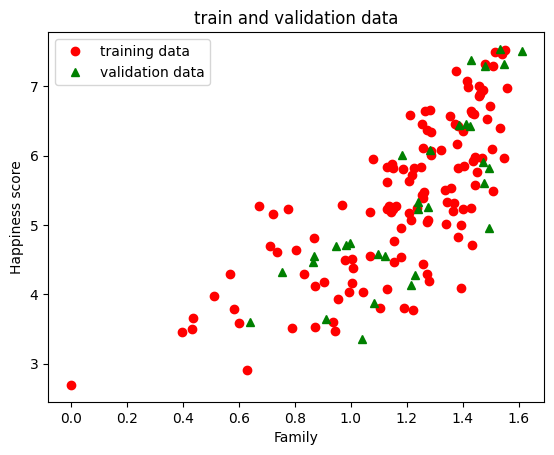

Functia calculata de tool : f(x) = 2.039013930022846 + 2.804913617557077 * x = y 
 w0 = 2.039013930022846 
 w1 = 2.804913617557077
Functia calculata de code : f(x) = 2.0390139300228274 + 2.804913617557092 * x = y 
 w0 = 2.0390139300228274 
 w1 = 2.804913617557092


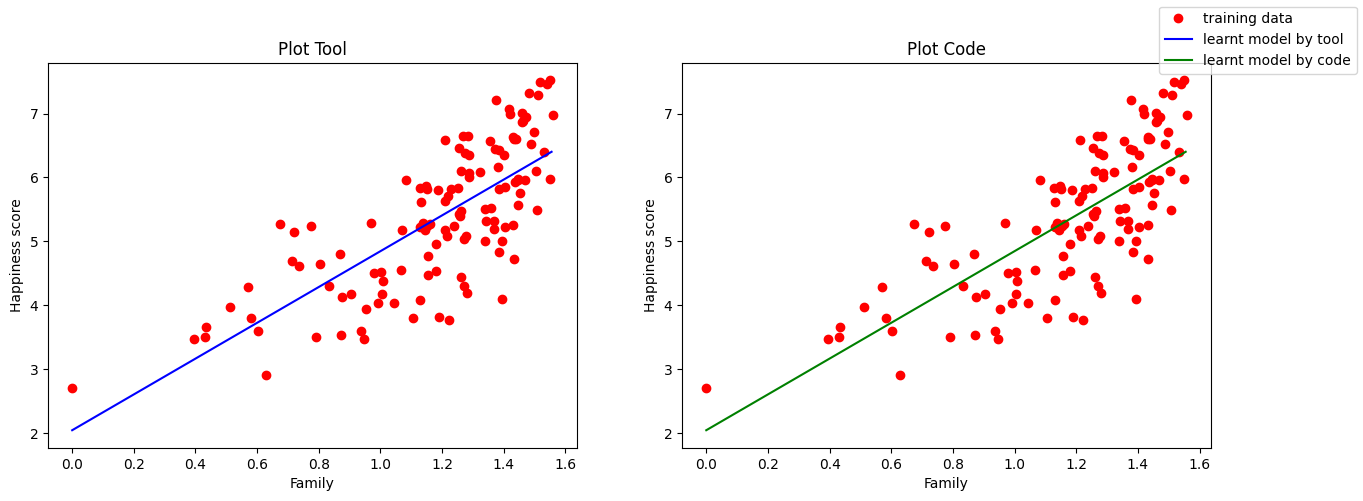

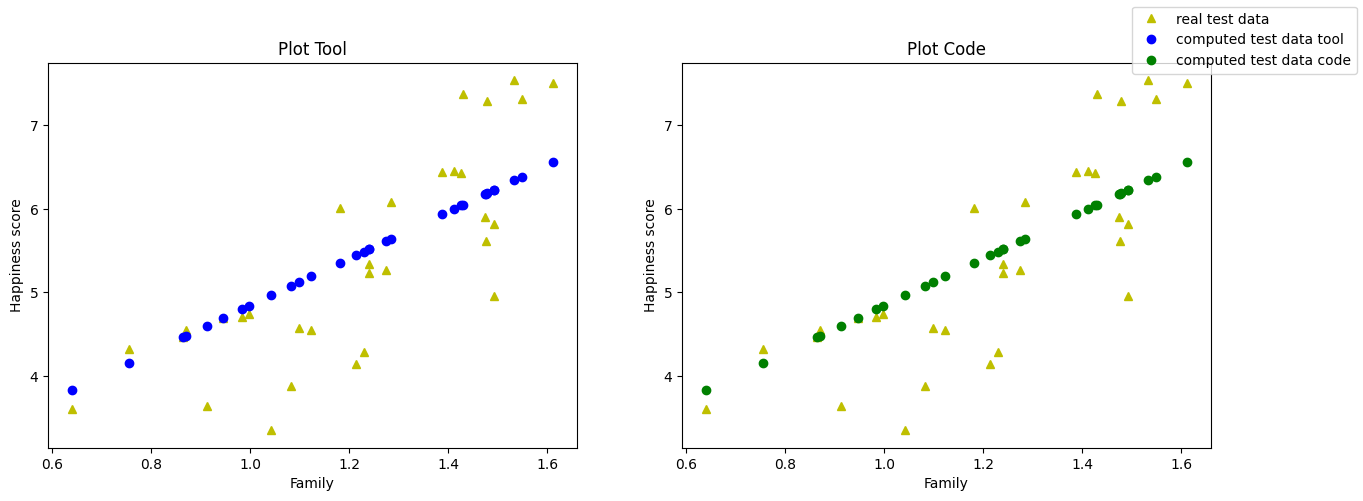

Erori outputs:
Eroare tool manuala : 0.6051231125473607
Eroare tool cu tool : 0.6051231125473586
Eroare code manuala : 0.6051231125473606
Eroare code cu tool : 0.6051231125473606


In [190]:
SolveRegresieUnivariata(filename='v2_world-happiness-report-2017.csv',
                inputVariabName='Family',
                outputVariableName='Happiness.Score',
                labelInput='Family',
                labelOutput='Happiness score')

### 3.de Produsul intern brut si de gradul de libertate.

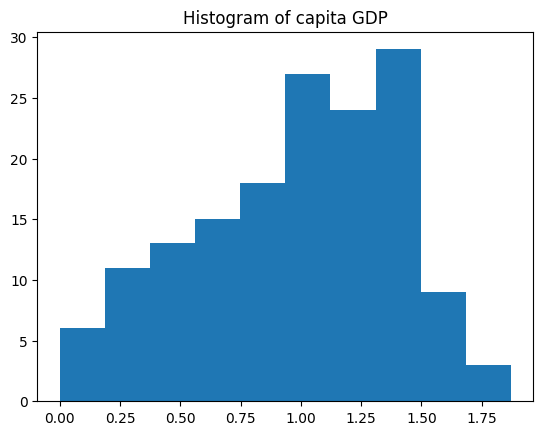

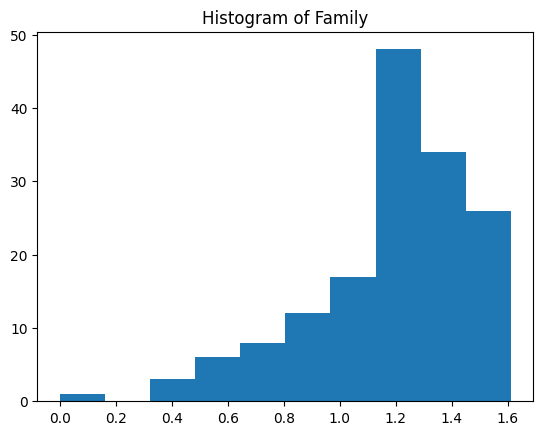

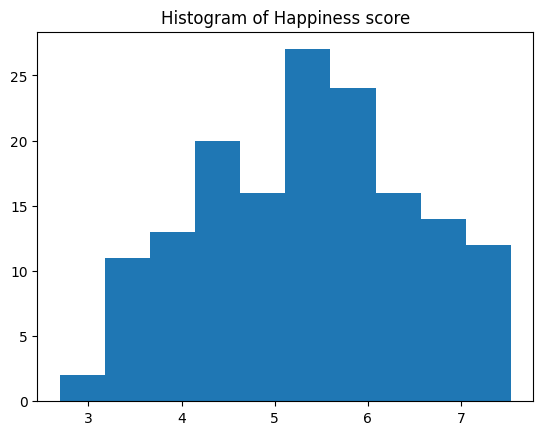

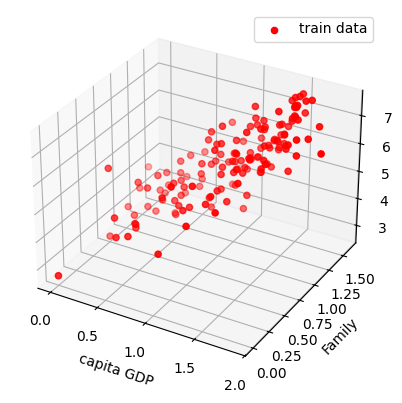

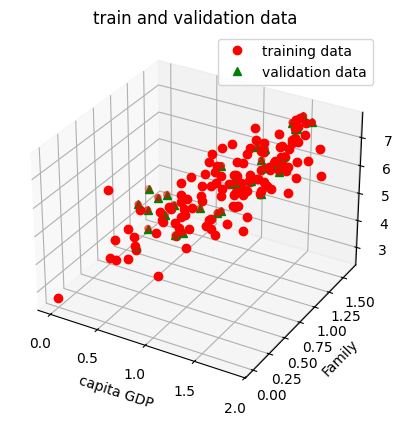

2.210885944388164
1.4646941168580385
1.4185441817784317
2.2108859443880537
1.4646941168578935
1.4185441817785405


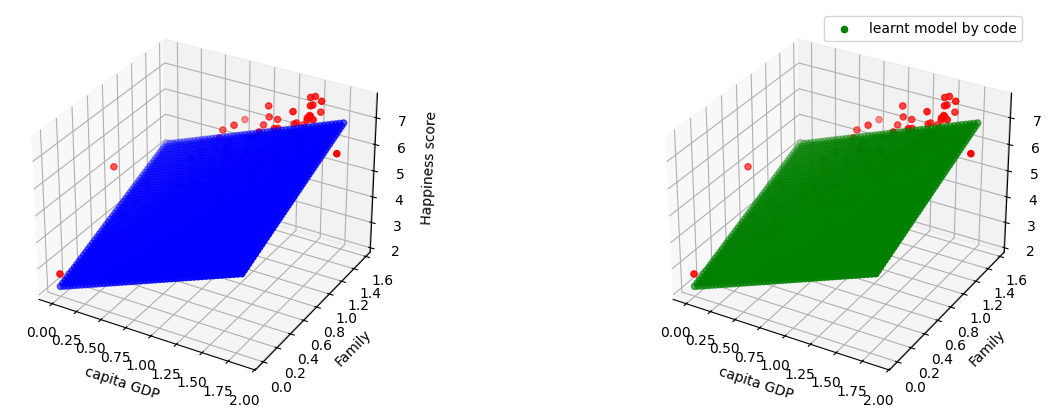

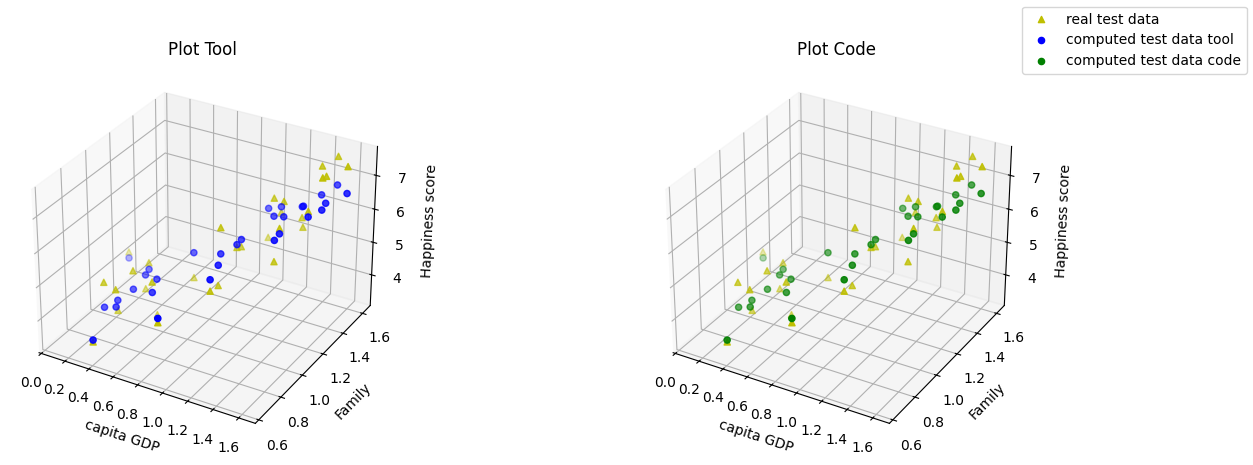

Erori outputs:
Eroare tool manuala : 0.3335443402515772
Eroare tool cu tool : 0.33354434025160207
Eroare code manuala : 0.3335443402515772
Eroare code cu tool : 0.3335443402515772


In [191]:
SolveRegresieBivariata(filename='v2_world-happiness-report-2017.csv',
               inputVariableNameFirst='Economy..GDP.per.Capita.',
               inputVariableNameSecond='Family',
               outputVariableName='Happiness.Score',
               labelInputFirst='capita GDP',
               labelInputSecond='Family',
               labelOuput='Happiness score')

## V3:

### 1. doar de Produsul intern brut 

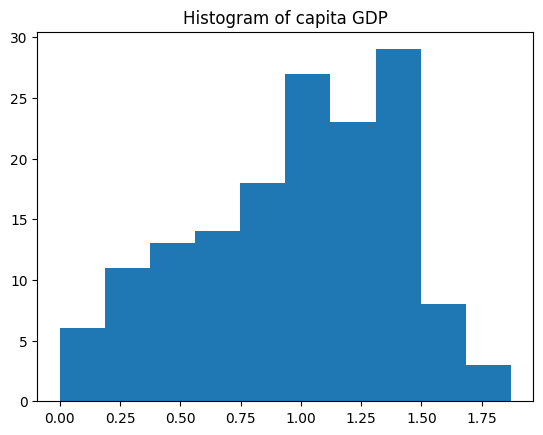

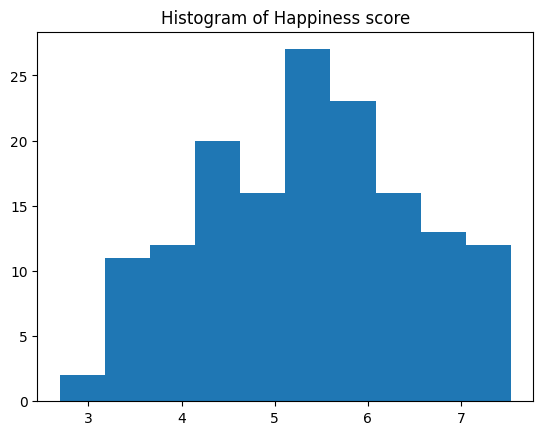

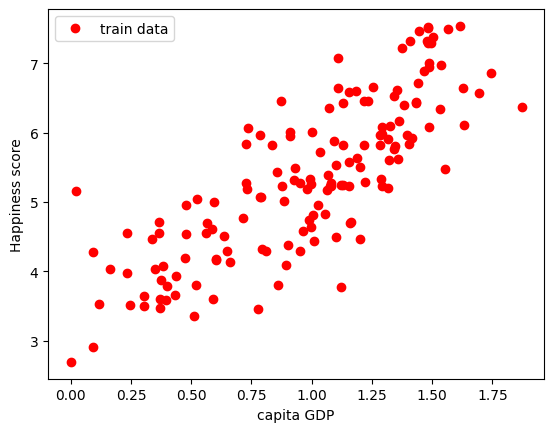

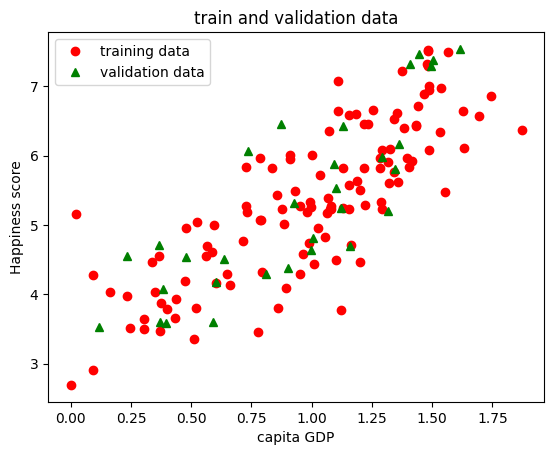

Functia calculata de tool : f(x) = 3.2590669479039853 + 2.109207536959527 * x = y 
 w0 = 3.2590669479039853 
 w1 = 2.109207536959527
Functia calculata de code : f(x) = 3.259066947903982 + 2.10920753695953 * x = y 
 w0 = 3.259066947903982 
 w1 = 2.10920753695953


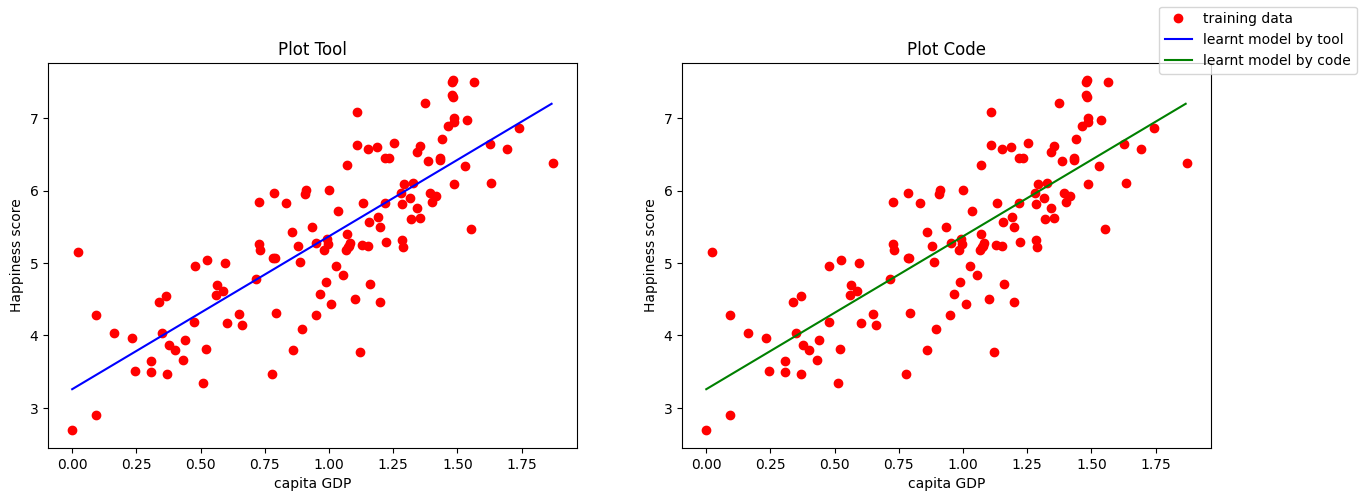

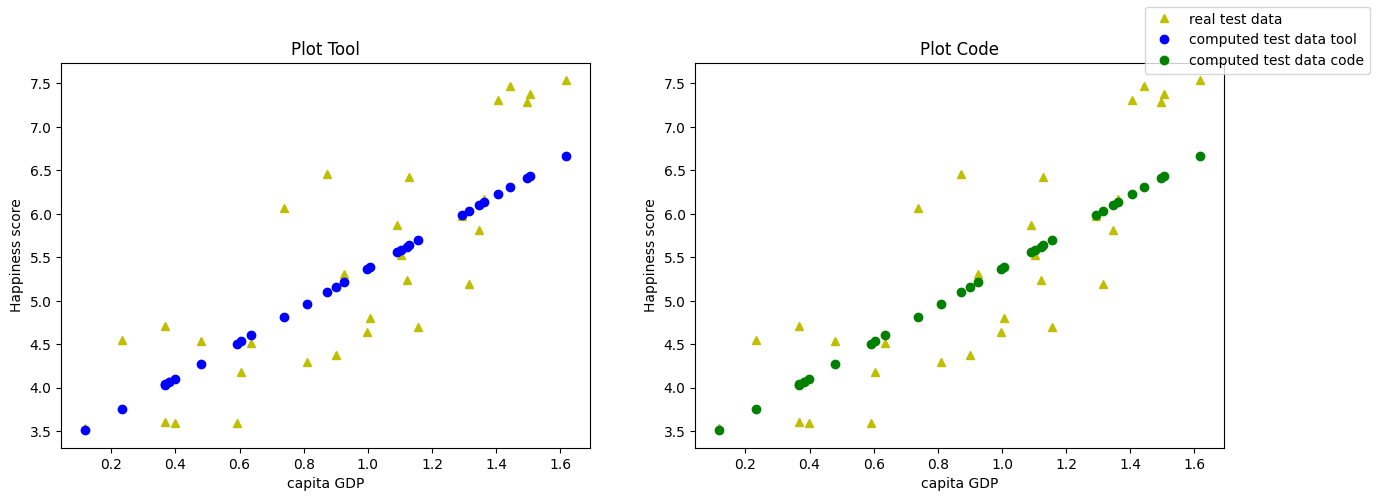

Erori outputs:
Eroare tool manuala : 0.5011920687289553
Eroare tool cu tool : 0.5011920687289552
Eroare code manuala : 0.5011920687289554
Eroare code cu tool : 0.5011920687289554


In [192]:
SolveRegresieUnivariata(filename='v3_world-happiness-report-2017.csv',
                inputVariabName='Economy..GDP.per.Capita.',
                outputVariableName='Happiness.Score',
                labelInput='capita GDP',
                labelOutput='Happiness score')

### 2. doar de caracteristica “Family”

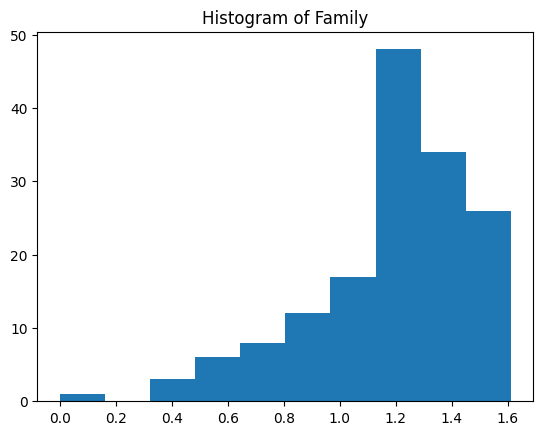

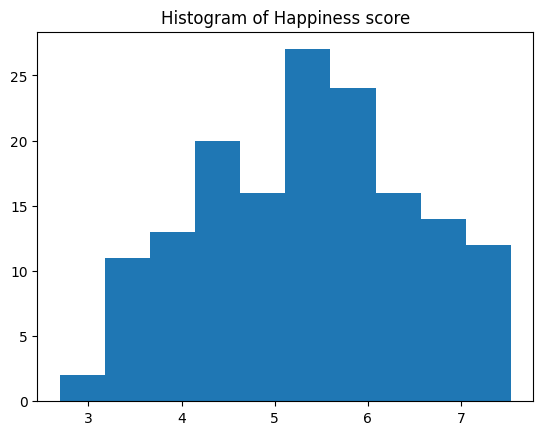

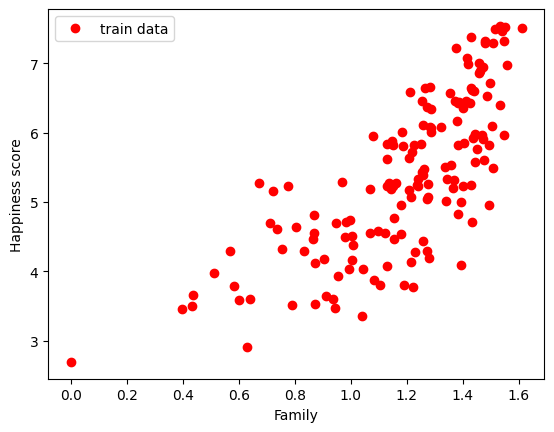

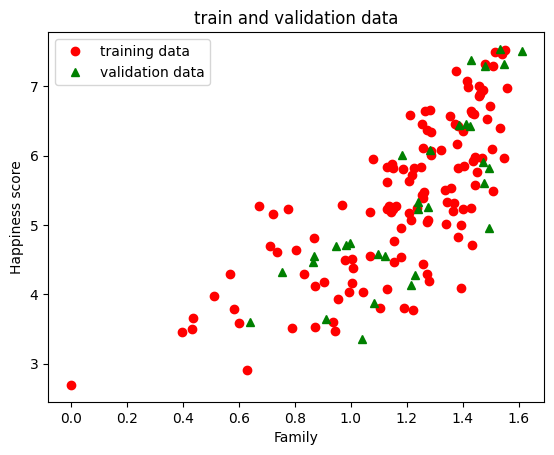

Functia calculata de tool : f(x) = 2.039013930022846 + 2.804913617557077 * x = y 
 w0 = 2.039013930022846 
 w1 = 2.804913617557077
Functia calculata de code : f(x) = 2.0390139300228274 + 2.804913617557092 * x = y 
 w0 = 2.0390139300228274 
 w1 = 2.804913617557092


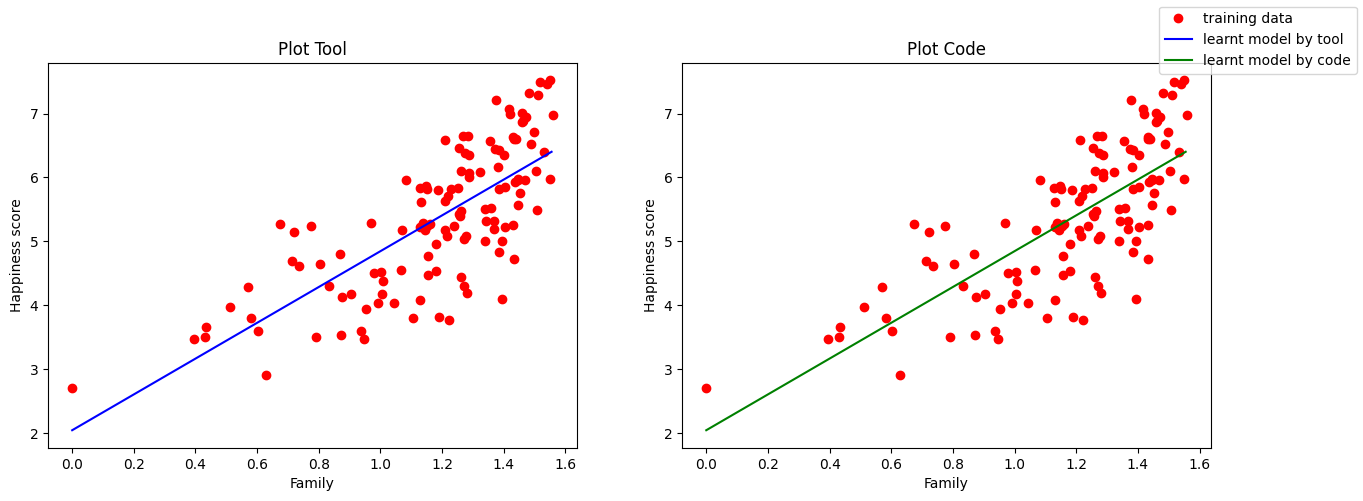

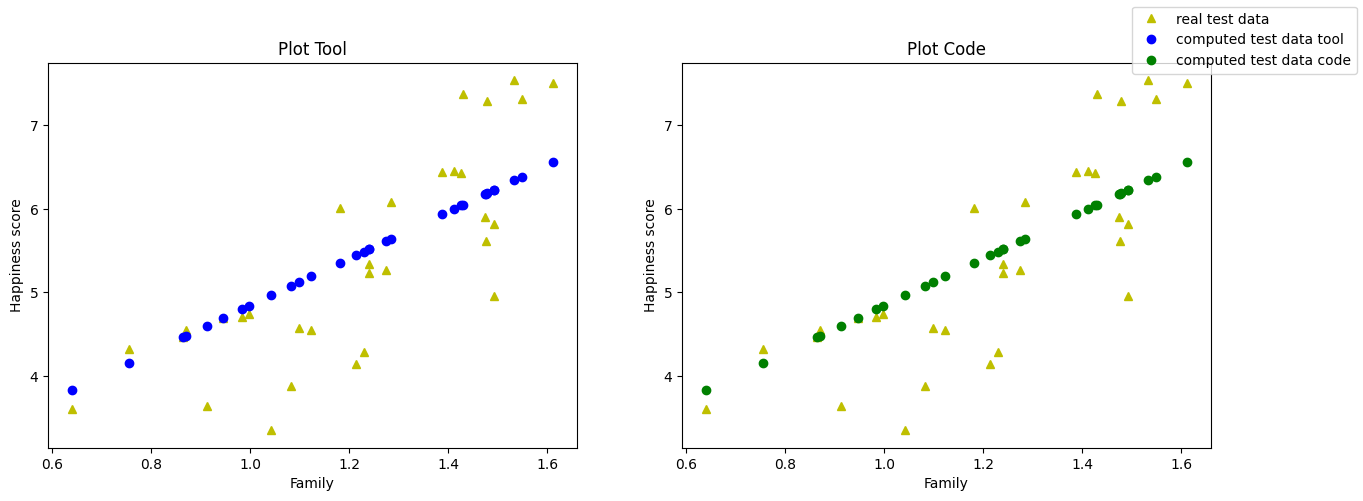

Erori outputs:
Eroare tool manuala : 0.6051231125473607
Eroare tool cu tool : 0.6051231125473586
Eroare code manuala : 0.6051231125473606
Eroare code cu tool : 0.6051231125473606


In [193]:
SolveRegresieUnivariata(filename='v3_world-happiness-report-2017.csv',
                inputVariabName='Family',
                outputVariableName='Happiness.Score',
                labelInput='Family',
                labelOutput='Happiness score')

### 3.de Produsul intern brut si de gradul de libertate.

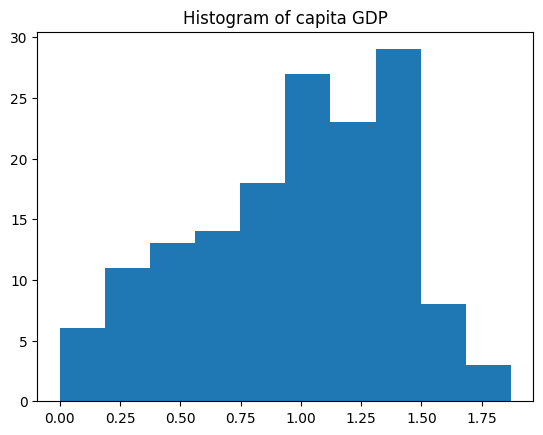

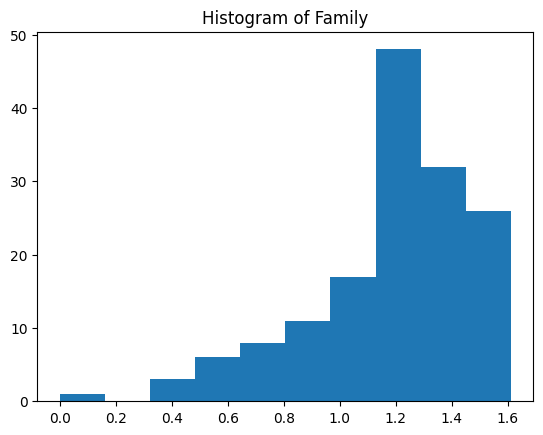

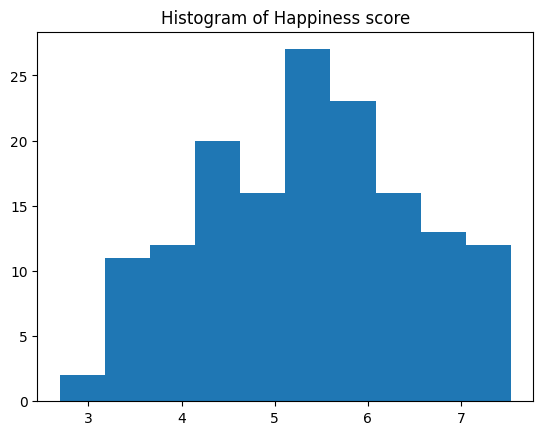

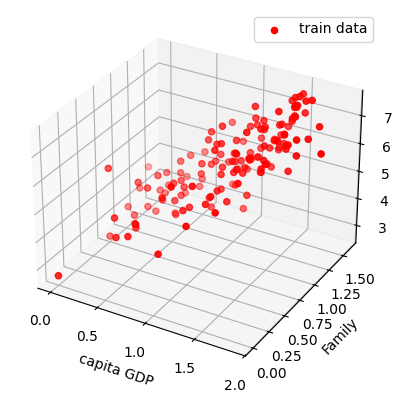

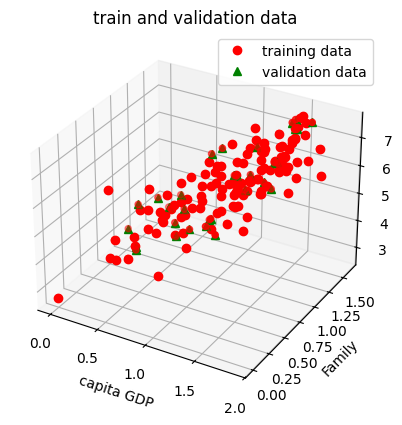

2.337928650378931
1.5325827681080189
1.245139316774131
2.3379286503788923
1.5325827681081023
1.245139316774142


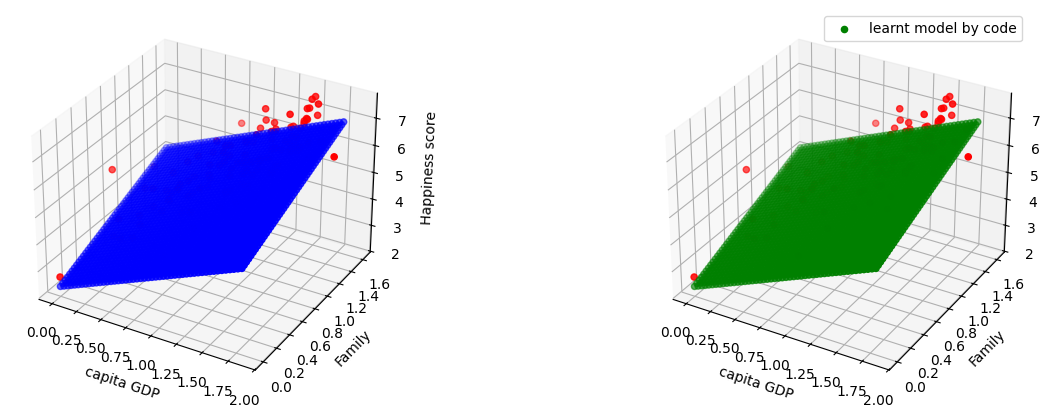

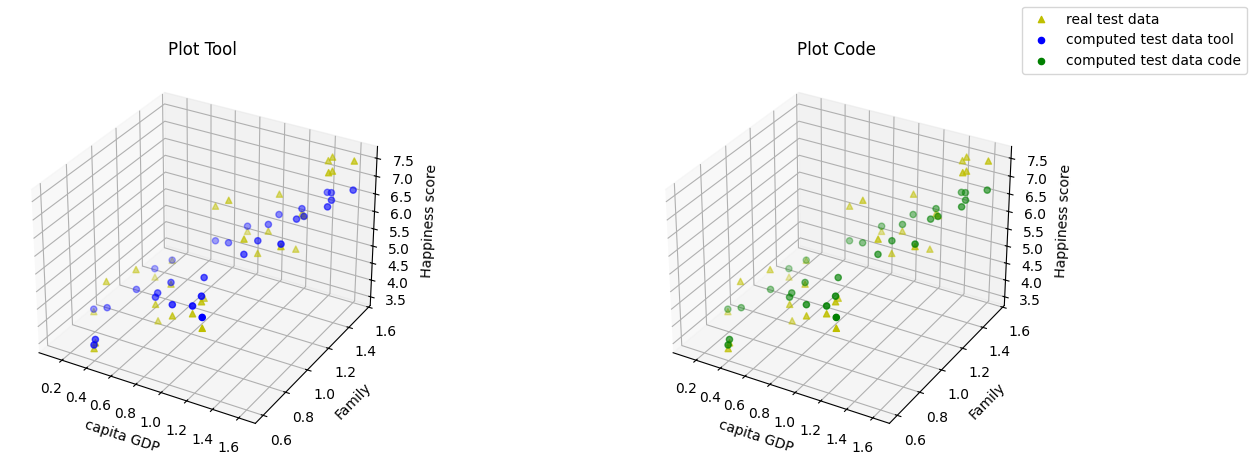

Erori outputs:
Eroare tool manuala : 0.33407871505564135
Eroare tool cu tool : 0.3340787150556168
Eroare code manuala : 0.33407871505564135
Eroare code cu tool : 0.33407871505564135


In [194]:
SolveRegresieBivariata(filename='v3_world-happiness-report-2017.csv',
               inputVariableNameFirst='Economy..GDP.per.Capita.',
               inputVariableNameSecond='Family',
               outputVariableName='Happiness.Score',
               labelInputFirst='capita GDP',
               labelInputSecond='Family',
               labelOuput='Happiness score')